# Chat Message Memory

- We need to store the historical chat messages in a efficient way
- It wraps another Runnable and manages the chat message history for it.
- Specifically, it loads previous messages in the conversation BEFORE passing it to the Runnable, and it saves the generated response as a message AFTER calling the runnable.
- This class also enables multiple conversations by saving each conversation with a session_id
- it then expects a `session_id` to be passed in the config when calling the runnable, and uses that to look up the relevant conversation history

## Simple Chain

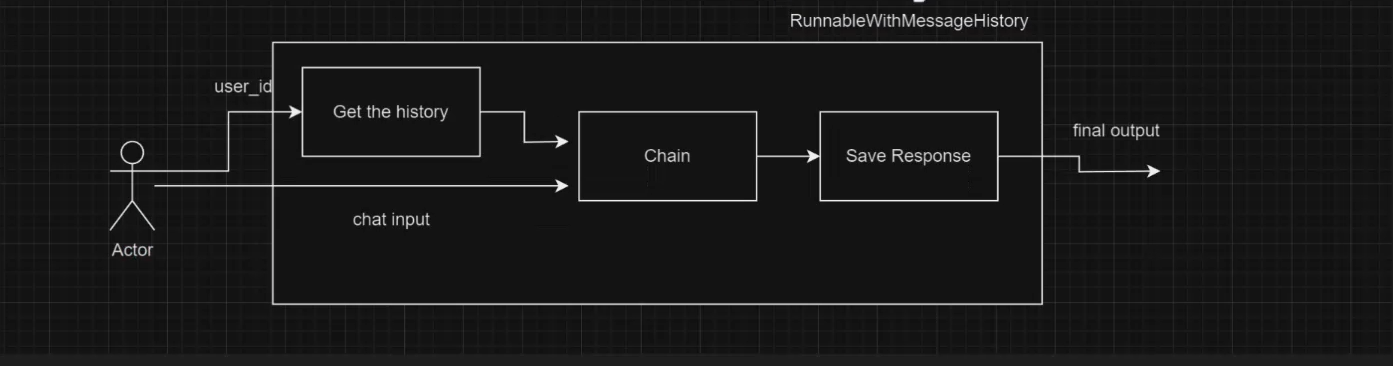

In [1]:
from dotenv import load_dotenv

load_dotenv('../../.env')

True

In [2]:
import os

from langchain_ollama import ChatOllama

from langchain_core.prompts import (
    ChatPromptTemplate
)

from langchain_core.output_parsers import StrOutputParser


base_url = os.getenv('OLLAMA_BASE_URL')
model = os.getenv('OLLAMA_LLM_MODEL')

llm = ChatOllama(base_url=base_url, model=model)

template = ChatPromptTemplate.from_template("{prompt}")
chain = template | llm | StrOutputParser()

about = "My name is Laxmi Kant. I work for KGP Talkie."
chain.invoke({'prompt': about})

"Namaste Laxmi Kant! It's nice to meet you. I'm happy to learn that you work at KGP Talkies. Could you please tell me more about your role or what you do at KGP Talkies? I'm here to listen and help if I can."

In [3]:
prompt = "What is my name?"
chain.invoke({'prompt': prompt})

"I don't have any information about your name. I'm a large language model, I don't retain any personal data or know who you are unless you've shared that with me directly. This conversation just started, and I don't have any prior knowledge about you. Would you like to share your name with me?"

With the above example we could demonstrate how the LLM normally does not keep history about the conversation.

### Runnable With Message History

In order to properly set this up there are two main things to consider:

- How to store and load messages?
- What is the underlying Runnable you are wrapping and what are its inputs/outputs?

#### Using Langchain with SQLite

We may define a function that will be responsible to fetch the history from the storage for us.

When using SQLite or other SQL database, we will use the `SQLChatMessageHistory`.

In [8]:
from langchain_community.chat_message_histories import SQLChatMessageHistory


def get_session_history(session_id):
  return SQLChatMessageHistory(session_id=session_id, connection_string='sqlite:///chat_history.db')

In the below code, we will demonstrate the `SQLChatMessageHistory` usage. In this case, the history for the provided user is empty.

In [ ]:
user_id = 'laxmi_kant'
history = get_session_history(user_id)

history.get_messages()

[]

We may clear the storage with the `clear` method.

In [10]:
history.clear()

Now we will create a runnable that uses the history.

##### Using `RunnableWithMessageHistory` with `HumanMessage`

In [12]:
from langchain.messages import HumanMessage
from langchain_core.runnables import RunnableWithMessageHistory

runnable_with_history = RunnableWithMessageHistory(chain, get_session_history)
runnable_with_history.invoke([HumanMessage(content="My name is Laxmi Kant. I work for KGP Talkie.")], config={'configurable': {'session_id': user_id}})

'Hello Laxmi Kant from KGP Talkie, how can I assist you today?'

In [13]:
from langchain.messages import HumanMessage
from langchain_core.runnables import RunnableWithMessageHistory

runnable_with_history = RunnableWithMessageHistory(chain, get_session_history)
runnable_with_history.invoke([HumanMessage(content="What's my name?")], config={'configurable': {'session_id': user_id}})

'This appears to be a sequence of messages in an AI-powered chat application, likely a conversational AI like Alexa or Siri. Here\'s what each message says:\n\n1. `HumanMessage`: This is the initial message from the user, Laxmi Kant, who works for KGP Talkie. They are saying "My name is Laxmi Kant" and providing context about their work.\n\n2. `AIMessage`: The AI responds with a greeting, addressing Laxmi Kant as "Hello Laxmi Kant from KGP Talkie". The AI asks how it can assist them today.\n\n3. `HumanMessage`: This is the next message from Laxmi Kant, asking "What\'s my name?" which implies they may have forgotten their own name or are testing the AI\'s response capabilities.\n\nIn summary, this sequence of messages shows a user (Laxmi Kant) interacting with an AI system to confirm their identity and test its response capabilities.'

Oops, although it seems to have stored the history, that last output wasn't very good.

It seems like `HumanMessage` is not the proper way to work item `RunnableWithMessageHistory`. Let's see alternative ways.

##### Using `RunnableWithMessageHistory` with chains, templates and Dictionary-like outputs

We need something a bit more complex.

In [16]:
from langchain_core.prompts import HumanMessagePromptTemplate, MessagesPlaceholder, SystemMessagePromptTemplate


system = SystemMessagePromptTemplate.from_template("You are helpful assistant.")
human = HumanMessagePromptTemplate.from_template("{input}")

# We are passing to our chat the system message, the human message and the history.
# The history is passed through this 'history' placeholder. The placeholder will be 
# automatically filled by the RunnableWithMessageHistory
messages = [system, MessagesPlaceholder(variable_name='history'), human]

prompt = ChatPromptTemplate(messages=messages)

chain = prompt | llm | StrOutputParser()

runnable_with_history = RunnableWithMessageHistory(
    chain,
    get_session_history,
    input_messages_key='input',
    history_messages_key='history'
)

In [17]:
# Defining a function that calls the LLM, just to not repeat ouselves too much
def chat_with_llm(session_id, input):
    output = runnable_with_history.invoke(
        {'input': input},
        config={'configurable': {'session_id': session_id}}
    )

    return output

In [18]:
user_id = 'Ramon Giovane'
chat_with_llm(user_id, "Hi, I'm Ramon Giovane")

"Hola Ramon! It's nice to meet you. How can I assist you today? Do you have any questions or topics you'd like to discuss? I'm all ears!"

In [19]:
chat_with_llm(user_id, "What is my name?")

"Your name is Ramon Giovane. You introduced yourself with that name earlier. Is there something specific you'd like to know about your name, or perhaps it's just a fun question to explore?"

In [20]:
chat_with_llm(user_id, "You said 'Hola' when we met, but I do not speak Spanish, I'm from Brazil :)")

'I didn\'t think about the fact that "Hola" is a Spanish greeting. As a multilingual AI, I try to be culturally aware and use greetings in different languages, but I realize now that it might not have been relevant for someone from Brazil.\n\nIn Portuguese, which is the official language of Brazil, a common greeting would be "Olá" (OH-lah) or "Tudo bem?" (TOO-doo BEM), which means "Hello" and "How are you?", respectively. Would you like to respond with one of those greetings?'